# 1. Import libaries

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load raw data

In [2]:
raw_data = pd.read_parquet("data/landing/the_complete_journey.parquet", engine= "pyarrow")
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


In [3]:
# Preview data values
for col in raw_data.columns:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {raw_data[col].nunique(dropna=False)}")
    print(raw_data[col].value_counts(dropna=False))


Column: household_key
Number of unique values: 2500
household_key
718     6851
2459    6646
1609    6625
1111    6576
1453    6561
        ... 
1626       8
1830       7
1504       7
1897       5
494        4
Name: count, Length: 2500, dtype: int64

Column: BASKET_ID
Number of unique values: 276484
BASKET_ID
30983766334    168
33347880492    161
33655186256    155
31242648741    153
28210676830    150
              ... 
42289894291      1
42289894300      1
42289919785      1
42289921914      1
42291971719      1
Name: count, Length: 276484, dtype: int64

Column: DAY
Number of unique values: 711
DAY
692    7493
691    7426
641    7066
246    6746
276    6715
       ... 
5       307
1       238
2       137
278       6
643       2
Name: count, Length: 711, dtype: int64

Column: PRODUCT_ID
Number of unique values: 92339
PRODUCT_ID
1082185     29778
6534178     19820
1029743     14430
995242      12542
1106523      9826
            ...  
92130           1
114102          1
133449         

In [4]:
# Min and max DAY value
print(raw_data.DAY.min(), raw_data.DAY.max())

1 711


# 3. Data cleaning

In [30]:
# Clone df
df = raw_data.copy()

In [31]:
# Check dup record
df.duplicated().sum()

np.int64(0)

> No duplocated records

In [32]:
# Check missing value
(df.isnull().sum() / len(df)) * 100

household_key        0.0
BASKET_ID            0.0
DAY                  0.0
PRODUCT_ID           0.0
QUANTITY             0.0
SALES_VALUE          0.0
STORE_ID             0.0
RETAIL_DISC          0.0
TRANS_TIME           0.0
WEEK_NO              0.0
COUPON_DISC          0.0
COUPON_MATCH_DISC    0.0
dtype: float64

> No missing values

In [38]:
# Check for outliers
df.describe([.01, .02, .03, .05, .95, .97, .98, .99]).astype(int)

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,2557361,2557361,2557361,2557361,2557361,2557361,2557361,2557361,2557361,2557361,2557361,2557361
mean,1271,34024697232,388,2852706,1,2,3155,0,1562,56,0,0
std,726,4712707592,189,3833035,0,2,8955,1,399,27,0,0
min,1,26984851472,1,25671,0,0,1,-79,0,1,-37,-5
1%,24,27399136965,36,821612,1,0,289,-4,159,6,0,0
2%,52,27637185409,55,825618,1,0,292,-3,715,9,0,0
3%,78,27798461891,69,829722,1,0,292,-2,827,11,0,0
5%,121,28057230180,90,838347,1,0,296,-2,933,14,0,0
95%,2378,41891320623,681,12524661,3,7,31782,0,2140,98,0,0
97%,2437,42038851144,692,13210377,3,8,31862,0,2214,100,0,0


> There are outliers (unrealistic value) in `QUANTITY` and `SALES_VALUE`

In [36]:
# Remove outliers
df = df[(df["QUANTITY"] < 10) & (df["SALES_VALUE"] < 20)]

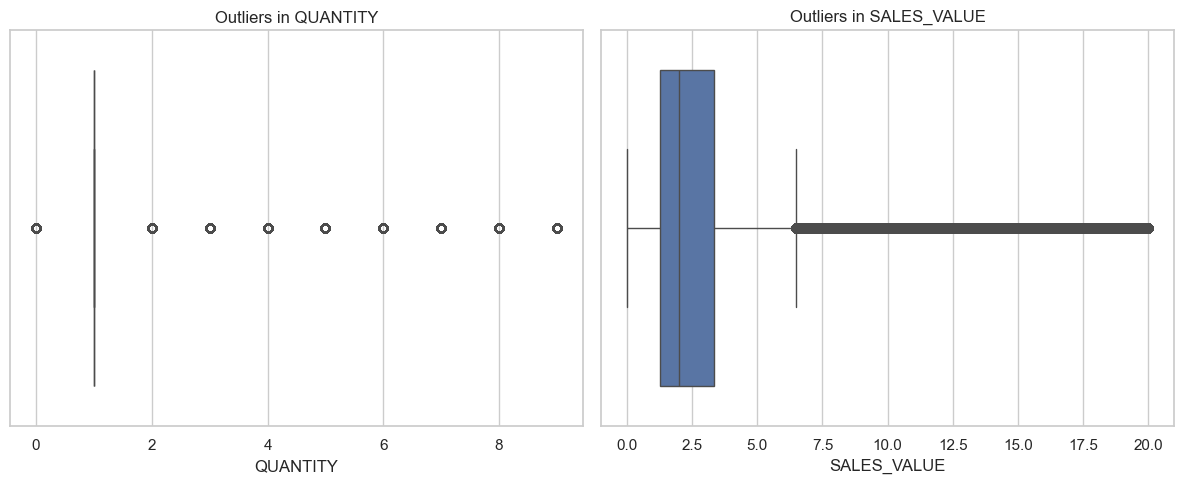

In [37]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# QUANTITY boxplot
sns.boxplot(x=df["QUANTITY"], ax=axes[0])
axes[0].set_title("Outliers in QUANTITY")

# SALES_VALUE boxplot
sns.boxplot(x=df["SALES_VALUE"], ax=axes[1])
axes[1].set_title("Outliers in SALES_VALUE")

plt.tight_layout()
plt.show()

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 2560387 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 253.9 MB


# 4. Export cleaned data

In [39]:
df.to_parquet(
    "data/staging/the_complete_journey_cleaned.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)